# Transformação de dados com Scikit-Learn

## Um cenário para motivação

Imagine que vamos construir um classificador para o famoso *dataset* [Iris](https://en.wikipedia.org/wiki/Iris_flower_data_set). Trata-se de um *dataset* composto de quatro informações sobre flores do tipo Iris: comprimento e largura de suas pétalas, e comprimento e largura de suas sépalas:

<img src="image.png" width=50%/>

Neste *dataset* temos 3 tipos de Iris, com 50 exemplos de cada. Os tipos são: "Iris setosa", "Iris versicolor" e "Iris virginica":

Iris setosa

<img src="setosa.png" width=33%/>

Iris versicolor

<img src="versicolor.png" width=33%/>

Iris virginica

<img src="virginica.png" width=33%/>

Este *dataset* pode ser facilmente obtido através da nossa principal biblioteca Python para Machine Learning: [Scikit-Learn](https://scikit-learn.org/)

<img src="sklearn-logo.png" width=25%/>


In [1]:
from sklearn.datasets import load_iris

dataset = load_iris(as_frame=True)

In [2]:
print(dataset.DESCR)  # type: ignore

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [3]:
df = dataset.frame  # type: ignore

In [4]:
target_names = dataset.target_names  # type: ignore
print(target_names)

['setosa' 'versicolor' 'virginica']


In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
X = df.drop(columns='target').copy()
y = df['target'].copy()

Como de costume, vamos efetuar a separação treino-teste antes de prosseguir:

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

**Atividade**

Explore o *dataset* de treino. São apenas 4 *features* contínuas e um *target* categórico, é simples, não precisa espernear de frustração!

In [8]:
X_train.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,120.000000,120.000000,120.000000,120.000000
mean,5.809167,3.061667,3.726667,1.183333
std,0.823805,0.449123,1.752345,0.752289
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.500000,0.300000
50%,5.750000,3.000000,4.250000,1.300000
75%,6.400000,3.400000,5.100000,1.800000
max,7.700000,4.400000,6.700000,2.500000


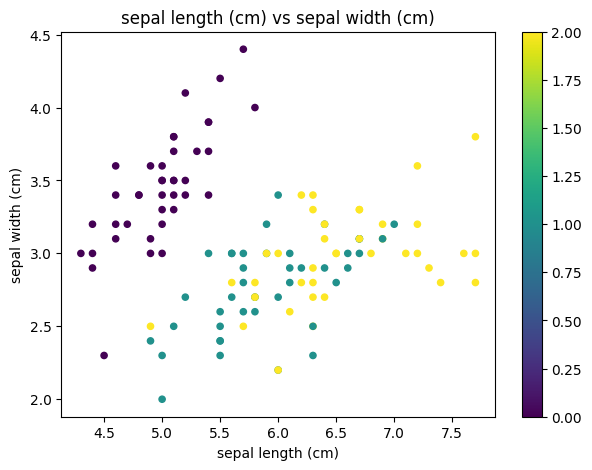

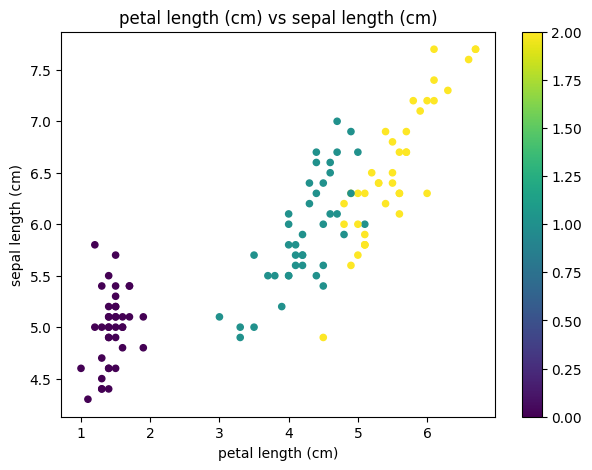

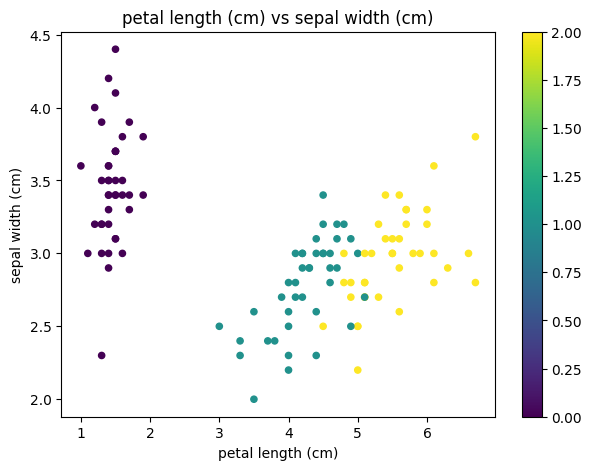

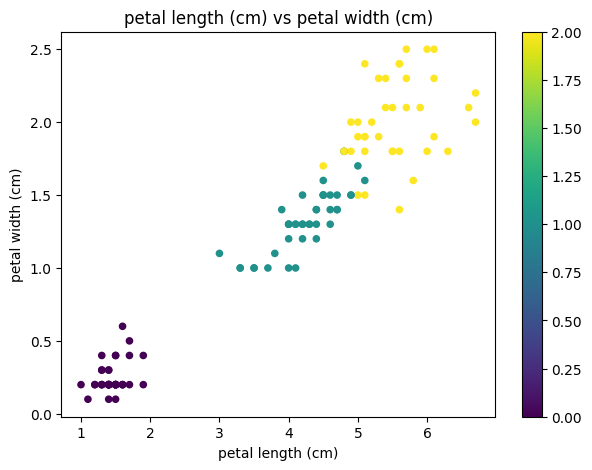

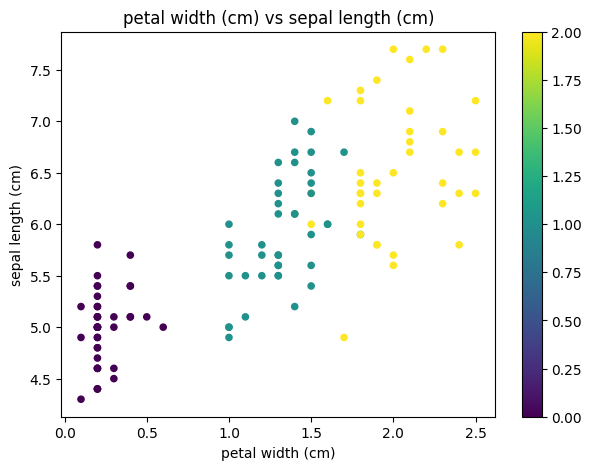

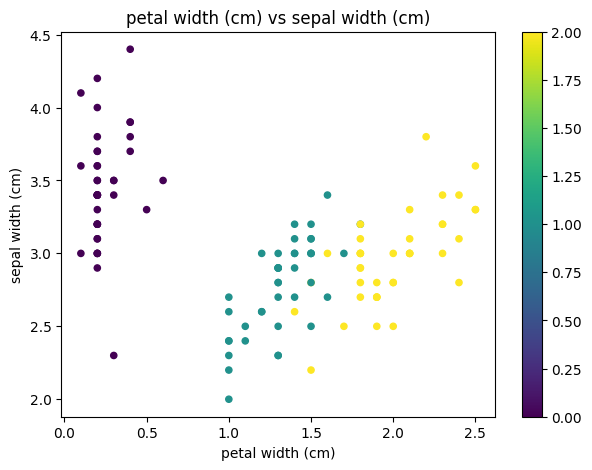

In [9]:
for c1 in X_train.columns:
    for c2 in X_train.columns:
        if c1 < c2:
            X_train.plot.scatter(
                c1,
                c2,
                figsize=(7, 5),
                c=y_train,
                cmap='viridis',
                title=f'{c1} vs {c2}',
            )

Suponha que você e sua equipe decidiram testar um classificador do tipo "k-Nearest Neighbors" - k-vizinhos mais próximos.

### Classificador KNN


O que é um classificador "k-Nearest Neighbors"?

Este é um modelo super simples:

- Define-se um valor $k$ inteiro positivo de vizinhos a serem buscados (já explico a seguir). Este valor impacta a capacidade de *generalização* do classificador, ou seja, controla se estamos em *overfitting* ou *underfitting* (lembra da aula 1?)
- No *treinamento* não tem muito a ser feito, é só guardar o *dataset* de treino na memória.
- Para fazer uma predição:
    - Devemos pegar o vetor de *features* da flor para a qual queremos saber o tipo (setosa, versicolor ou virginica) e localizar os $k$ vizinhos mais próximos desta nova flor no conjunto de treino, ou seja, os $k$ pontos de treino cujos vetores de *features* tem a menor distância em relação ao vetor de *features* desta nova flor.
    - Agora estes $k$ vizinhos "votam" entre si para decidir qual a classe que eles "acham" que esta nova flor deve ter. Cada um "vota" com sua própria classe.

Por exemplo, imagine que nosso classificador usa $k = 4$ vizinhos (escolha nossa). Temos agora uma nova flor Iris (do conjunto de teste, ou então de algum usuário do nosso aplicativo viral "Que flor Iris é essa?") e queremos saber o que nosso classificador acha dela. Ao localizar os quatro (valor de $k$, lembra?) vizinhos mais próximos da nova flor, vemos que estes são 3 setosas e uma versicolor. Pela democracia das flores Iris, nosso classificador decide então que a nova flor é uma setosa!

Sim, tosco assim mesmo. Mas é um modelo de classificação surpreendentemente poderoso, embora pouco eficiente na geração de predições (cada nova predição requer a busca dos $k$ vizinhos mais próximos no conjunto de treino inteirinho!). Você mesmo usa esse classificador o tempo todo, ou a versão "regressor" dele, quer ver?

**Atividade**

Discuta com seus colegas e pense em situações onde **você** foi o classificador "k-Nearest Neighbors" humano! 

Este classificador já está implementado no Scikit-Learn:

In [10]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=4)

In [11]:
model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Podemos treinar esse modelo criado:

In [12]:
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Agora podemos usar o modelo já treinado para fazer novas predições:

In [13]:
y_pred = model.predict(X_test)

In [14]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Aparentemente esse classificador já acertou tudo sem preprocessamento nenhum, sem nada extra!

MAAAAASSSS... faz-de-conta que não foi assim, só para a gente brincar um pouco.

### Normalização de dados

Ok, voltando ao tema da aula. Bem, como o classificador "k-Nearest Neighbor" efetua um cálculo de distâncias entre pontos, é importante que as *escalas* das *features* sejam parecidas. Por que?

**Atividade**

Se as larguras de pétala e sépala fossem sempre da ordem de poucos centímetros, mas os respectivos comprimentos fossem da ordem de **dezenas** de centímetros (sei lá, são flores alienígenas), como isso impactaria esse classificador "k-Nearest Neighbors"?

Portanto, sendo cauteloso, você gostaria de "normalizar" as features, ou seja, para cada feature:

- Subtrai o valor da mediana;
- Divide pelo valor do intervalo inter-quartil.

Podemos fazer isso com nosso *dataset* de treino facilmente, não?

In [16]:
import pandas as pd


def normalize(some_X: pd.DataFrame) -> pd.DataFrame:
    # Calcula os parâmetros de normalização (mediana e IQR) para cada coluna.
    median_value_per_column = some_X.median()
    iqr_value_per_column = some_X.quantile(0.75) - some_X.quantile(0.25)

    # Aplica a normalização usando os parâmetros calculados.
    return (some_X - median_value_per_column) / iqr_value_per_column


X_train_normalized = normalize(X_train)

(Pandas, que beleza!)

In [17]:
X_train.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,120.000000,120.000000,120.000000,120.000000
mean,5.809167,3.061667,3.726667,1.183333
std,0.823805,0.449123,1.752345,0.752289
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.500000,0.300000
50%,5.750000,3.000000,4.250000,1.300000
75%,6.400000,3.400000,5.100000,1.800000
max,7.700000,4.400000,6.700000,2.500000


In [18]:
X_train_normalized.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,120.000000,120.000000,120.000000,120.000000
mean,0.045513,0.102778,-0.145370,-0.077778
std,0.633696,0.748538,0.486762,0.501526
min,-1.115385,-1.666667,-0.902778,-0.800000
25%,-0.500000,-0.333333,-0.763889,-0.666667
50%,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.666667,0.236111,0.333333
max,1.500000,2.333333,0.680556,0.800000


E com isso podemos treinar nosso modelo:

In [19]:
model.fit(X_train_normalized, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Fazendo novas predições

Ok, o modelo está treinado. Agora suponha que queremos prever a classe de uma nova flor, com os seguintes atributos:

- Comprimento da sépala: $6.1$ cm
- Largura da sépala: $2.8$ cm
- Comprimento da pétala: $4.7$ cm
- Largura da pétala: $1.2$ cm

Para usar o modelo para fazer predições, devemos montar um novo *Dataframe* com esses dados e então pedir ao modelo que faça as predições:

In [20]:
# Note que as colunas deste novo Dataframe são as mesmas do DataFrame de treino.
X_nova_flor = pd.DataFrame(
    {
        'sepal length (cm)': [6.1],
        'sepal width (cm)': [2.8],
        'petal length (cm)': [4.7],
        'petal width (cm)': [1.2],
    }
)

In [21]:
y_pred_da_nova_flor = model.predict(X_nova_flor)

In [22]:
y_pred_da_nova_flor

array([2])

In [23]:
classe_da_nova_flor = y_pred_da_nova_flor[0]
print(f'A nova flor pertence à classe {classe_da_nova_flor}')

A nova flor pertence à classe 2


Ok, e esse número significa o que?

In [24]:
nome_da_classe_da_nova_flor = target_names[classe_da_nova_flor]
print(f'A nova flor pertence à classe "{nome_da_classe_da_nova_flor}"')

A nova flor pertence à classe "virginica"


Missão cumprida! Temos a classe da nova flor!

Exceto que... essa flor não foi escolhida ao acaso, trata-se da primeira flor do *dataset* de teste, e eu sei que ela é, na verdade, uma Iris Versicolor... o classificador errou.

O que deu errado aqui? Ah, faltou "normalizar" as *features* da nova flor! Vamos tentar de novo:

In [25]:
X_nova_flor_normalizada = normalize(X_nova_flor)

In [26]:
X_nova_flor_normalizada

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,NaN,NaN,NaN,NaN


Ops, deu ruim...

**Atividade**

Por que?

Pois bem, então não dá para "normalizar" uma amostra só. O certo é **usar os parâmetros de normalização que foram calculados no conjunto de treino**! 

Vamos modificar nosso código para separar o **aprendizado dos parâmetros de normalização** da **aplicação da operação de normalização**:

In [27]:
def compute_normalization_parameters(
    some_X: pd.DataFrame,
) -> tuple[pd.Series, pd.Series]:
    median_value = some_X.median()
    iqr_value = some_X.quantile(0.75) - some_X.quantile(0.25)
    return median_value, iqr_value


def normalize_with_parameters(
    some_X: pd.DataFrame,
    median_value: pd.Series,
    iqr_value: pd.Series,
) -> pd.DataFrame:
    return (some_X - median_value) / iqr_value

Podemos agora normalizar o conjunto de treino da seguinte maneira:

In [28]:
median_value_train, iqr_value_train = compute_normalization_parameters(X_train)
X_train_normalized = normalize_with_parameters(
    X_train, median_value_train, iqr_value_train
)

Podemos treinar o classificador com esse *dataset* normalizado:

In [29]:
model.fit(X_train_normalized, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Agora, a nova flor. Vamos normaliza-la com os parâmetros aprendidos:

In [30]:
X_nova_flor_normalizada = normalize_with_parameters(
    X_nova_flor,
    median_value_train,
    iqr_value_train,
)

In [31]:
X_nova_flor_normalizada

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.269231,-0.333333,0.125,-0.066667


Ah, muito melhor! Vamos fazer a predição:

In [32]:
y_pred_da_nova_flor_normalizada = model.predict(X_nova_flor_normalizada)
y_pred_da_nova_flor_normalizada

array([1])

In [33]:
classe_da_nova_flor = y_pred_da_nova_flor_normalizada[0]
nome_da_classe_da_nova_flor = target_names[classe_da_nova_flor]
print(f'A nova flor pertence à classe "{nome_da_classe_da_nova_flor}"')

A nova flor pertence à classe "versicolor"


Tudo está correto agora, que beleza!

### Organizando o código

Nosso código de normalização de dados tem:

- os parâmetros da normalização
- a função que ***ajusta*** esses parâmetros
- a função que ***transforma*** os dados

Podemos organizar esses pedaços de solução em uma entidade unificada: uma *classe*.

In [34]:
from typing import Self


class Normalizer:
    def __init__(self):
        self.median_value = None
        self.iqr_value = None

    def fit(self, some_X: pd.DataFrame) -> Self:
        self.median_value, self.iqr_value = compute_normalization_parameters(some_X)
        return self

    def transform(self, some_X: pd.DataFrame) -> pd.DataFrame:
        if self.median_value is None or self.iqr_value is None:
            raise ValueError(
                'The normalizer instance is not fitted yet. '
                "Call 'fit' with appropriate data before using this method."
            )
        return normalize_with_parameters(some_X, self.median_value, self.iqr_value)

    def fit_transform(self, some_X: pd.DataFrame) -> pd.DataFrame:
        return self.fit(some_X).transform(some_X)

Vamos testar o procedimento anterior para ver se tudo ainda funciona. Vamos criar nosso normalizador:

In [35]:
normalizer = Normalizer()

Agora vamos:

- Ajustar e já aplicar o normalizador nos dados de treino
- Treinar o classificador

In [36]:
X_train_normalized = normalizer.fit_transform(X_train)
model.fit(X_train_normalized, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Ficou limpinho! Vamos usar o normalizador e o classificador para fazer a predição para a nova flor:

In [37]:
X_nova_flor_normalizada = normalizer.transform(X_nova_flor)
y_pred_da_nova_flor_normalizada = model.predict(X_nova_flor_normalizada)

In [38]:
classe_da_nova_flor = y_pred_da_nova_flor_normalizada[0]
nome_da_classe_da_nova_flor = target_names[classe_da_nova_flor]
print(f'A nova flor pertence à classe "{nome_da_classe_da_nova_flor}"')

A nova flor pertence à classe "versicolor"


Pronto, ficou joia! Em resumo, nesta seção vimos:

- Nosso primeiro classificador: o "k-Nearest Neighbors"!
- Como implementar um *transformador* de dados para normalizar valores

A boa notícia é que ***Scikit-Learn tem VÁRIOS transformadores já implementados***! Vamos explorar alguns deles neste *notebook*.

## Transformadores no Scikit-Learn

O Scikit-Learn já tem vários transformadores implementados. Explore a documentação do Scikit-Learn em https://scikit-learn.org/stable/data_transforms.html, em particular as seções de [pré-processamento](https://scikit-learn.org/stable/modules/preprocessing.html) de dados e de [imputação de valores faltantes](https://scikit-learn.org/stable/modules/impute.html).

**Atividade**

Consulte a documentação do Scikit-Learn e descubra transformadores para as seguintes tarefas:

- Normalizar as colunas, mas desta vez através da subtração da *média* e divisão pelo *desvio padrão*
- Discretizar uma *feature* contínua e transformá-la em categórica, através da categorização dos valores contínuos em *bins*, ou faixas de valores
- Adicionar novas colunas ao *dataset* que são termos *polinomiais* das colunas existentes, para um grau especificado de polinômio
- Transformar uma *feature* categórica em um conjunto de *features* numéricas binárias (valendo zero ou um) sendo uma *feature* binária por categoria. Ou seja, se uma *feature* categórica `fruta` tem categorias `abacaxi`, `pera`, `banana`, remove esta *feature* e substitui por três novas *features*: `fruta_abacaxi`, `fruta_pera` e `fruta_banana`
- Preencher dados faltantes, substituindo os buracos pelo valor mediano da *feature*


- Normalizar as colunas, mas desta vez através da subtração da *média* e divisão pelo *desvio padrão*

`sklearn.preprocessing.StandardScaler`

- Discretizar uma *feature* contínua e transformá-la em categórica, através da categorização dos valores contínuos em *bins*, ou faixas de valores

`sklearn.preprocessing.KBinsDiscretizer`

- Adicionar novas colunas ao *dataset* que são termos *polinomiais* das colunas existentes, para um grau especificado de polinômio

`sklearn.preprocessing.PolynomialFeatures`

- Transformar uma *feature* categórica em um conjunto de *features* numéricas binárias (valendo zero ou um) sendo uma *feature* binária por categoria. Ou seja, se uma *feature* categórica `fruta` tem categorias `abacaxi`, `pera`, `banana`, remove esta *feature* e substitui por três novas *features*: `fruta_abacaxi`, `fruta_pera` e `fruta_banana`

`sklearn.preprocessing.OneHotEncoder`

- Preencher dados faltantes, substituindo os buracos pelo valor mediano da *feature*

`sklearn.impute.SimpleImputer`


Vamos praticar com um velho conhecido nosso, o "California Housing" modificado do nosso livro-texto!

In [39]:
df = pd.read_csv('housing.csv')

In [40]:
X = df.drop(columns='median_house_value').copy()
y = df['median_house_value'].copy()

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [42]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16349 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  str    
dtypes: float64(8), str(1)
memory usage: 1.3 MB


In [ ]:
# Este truque é necessário para que as transformações do sklearn retornem DataFrames do
# pandas, ao invés de arrays do NumPy. Isso é útil para manter as colunas nomeadas e
# facilitar a manipulação dos dados. Sem isso, as transformações retornariam arrays do
# NumPy, que não possuem nomes de colunas, o que pode dificultar a interpretação dos
# resultados e a depuração do código.
from sklearn import set_config

set_config(transform_output='pandas')

**Atividade**

Copie todas as colunas de *feature* contínuas do Dataframe `X_train` para um novo Dataframe `X_train_continuas` e faça o seguinte:

1. Treine e aplique (com o método `fit_transform`) um transformador do tipo `SimpleImputer`, gerando assim um novo Dataframe `X_train_imputed`. Observe que não tem mais dados faltantes.
1. Agora treine e aplique neste novo Dataframe um transformador do tipo `PolynomialFeatures(degree=2, include_bias=False)` para criar um Dataframe `X_train_poly`, observe o resultado.
1. Agora treine e aplique um transformador `StandardScaler`, gerando um Dataframe `X_train_scaled`


In [44]:
num_columns = [
    'longitude',
    'latitude',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income',
]

X_train_continuas = X_train[num_columns].copy()

In [45]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer()
X_train_imputed = imputer.fit_transform(X_train_continuas)

In [46]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_imputed)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)

**Atividade**

1. Copie as colunas categóricas do Dataframe `X_train` (só tem uma, a `ocean_proximity`) para um Dataframe `X_train_categoricas`
1. Aplique o transformador `OneHotEncoder(sparse_output=False)` neste Dataframe e gere um Dataframe `X_train_one_hot_encoded`, observe o resultado


In [48]:
cat_columns = ['ocean_proximity']
X_train_categoricas = X_train[cat_columns].copy()
X_train_categoricas

,ocean_proximity
14196,NEAR OCEAN
8267,NEAR OCEAN
17445,NEAR BAY
14265,<1H OCEAN
2271,INLAND
...,...
11284,NEAR BAY
11964,<1H OCEAN
5390,INLAND
860,INLAND


In [49]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
X_train_one_hot_encoded = encoder.fit_transform(X_train_categoricas)

In [50]:
X_train_one_hot_encoded

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,0.0,0.0,0.0,0.0,1.0
8267,0.0,0.0,0.0,0.0,1.0
17445,0.0,0.0,0.0,1.0,0.0
14265,1.0,0.0,0.0,0.0,0.0
2271,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...
11284,0.0,0.0,0.0,1.0,0.0
11964,1.0,0.0,0.0,0.0,0.0
5390,0.0,1.0,0.0,0.0,0.0
860,0.0,1.0,0.0,0.0,0.0


**Atividade**

Junte os dois resultados finais anteriores (`X_train_scaled` e `X_train_one_hot_encoded`) em um único Dataframe `X_train_transformed`

In [51]:
X_train_transformed = pd.concat([X_train_scaled, X_train_one_hot_encoded], axis=1)

In [52]:
X_train_transformed.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,longitude^2,longitude latitude,...,population households,population median_income,households^2,households median_income,median_income^2,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,1.172993,-1.350415,0.428537,1.570557,1.374785,1.081011,1.507507,0.379698,-1.166868,1.314692,...,0.557920,1.211232,0.773203,1.594423,0.111379,0.0,0.0,0.0,0.0,1.0
8267,1.268028,-1.378536,-1.473509,-0.809439,-0.903400,-0.643842,-0.878707,0.420068,-1.259726,1.355639,...,-0.315825,-0.411886,-0.374998,-0.621245,0.143342,0.0,0.0,0.0,0.0,1.0
17445,-1.352939,0.988349,-0.046974,1.994289,2.439380,1.363196,2.593828,-0.092320,1.356415,-1.082910,...,1.060141,0.991166,1.851545,1.891049,-0.222861,0.0,0.0,0.0,1.0,0.0
14265,-1.127856,0.758691,-0.284730,0.646558,0.228483,0.661262,0.394820,0.682999,1.127249,-0.845860,...,0.100192,1.043130,0.029082,0.759338,0.364530,1.0,0.0,0.0,0.0,0.0
2271,1.793222,-1.083261,-1.632013,-1.117906,-1.184568,-1.203802,-1.255755,-1.255560,-1.770173,1.235860,...,-0.352668,-0.987529,-0.402967,-1.019387,-0.736107,0.0,1.0,0.0,0.0,0.0


Agora teríamos que repetir TUDO isso para `X_test`, depois para qualquer novo *dataset*, etc.... que tédio. Felizmente o Scikit-Learn tem ferramentas para combinar transformadores, que veremos na próxima aula!

In [53]:
X_test_continuas = X_test[num_columns].copy()

In [54]:
X_test_imputed = imputer.transform(X_test_continuas)
X_test_poly = poly.transform(X_test_imputed)
X_test_scaled = scaler.transform(X_test_poly)

In [55]:
X_test_categoricas = X_test[cat_columns].copy()

In [56]:
X_test_one_hot_encoded = encoder.transform(X_test_categoricas)

In [57]:
X_test_transformed = pd.concat([X_test_scaled, X_test_one_hot_encoded], axis=1)

In [58]:
from typing import Self

In [59]:
class Pipeline:
    def __init__(self, transforms: list) -> None:
        self.transforms = transforms

    def fit(self, some_X: pd.DataFrame) -> Self:
        aux_df = some_X.copy()
        for transform in self.transforms:
            aux_df = transform.fit_transform(aux_df)
        return self
    
    def transform(self, some_X: pd.DataFrame) -> pd.DataFrame:
        aux_df = some_X.copy()
        for transform in self.transforms:
            aux_df = transform.transform(aux_df)
        return aux_df

    def fit_transform(self, some_X: pd.DataFrame) -> pd.DataFrame:
        return self.fit(some_X).transform(some_X)

In [60]:
class TransformaTudo:
    def __init__(
        self,
        transformador_continuas,
        num_columns: list[str],
        transformador_categoricas,
        cat_columns: list[str],
    ) -> None:
        self.num_columns = num_columns
        self.cat_columns = cat_columns
        self.transf_num = transformador_continuas
        self.transf_cat = transformador_categoricas

    def fit(self, some_X: pd.DataFrame) -> Self:
        num_data = some_X[self.num_columns].copy()
        self.transf_num.fit(num_data)

        cat_data = some_X[self.cat_columns].copy()
        self.transf_cat.fit(cat_data)

        return self

    def transform(self, some_X: pd.DataFrame) -> pd.DataFrame:
        num_data = some_X[self.num_columns].copy()
        transf_num_data = self.transf_num.transform(num_data)

        cat_data = some_X[self.cat_columns].copy()
        transf_cat_data = self.transf_cat.transform(cat_data)

        return pd.concat([transf_num_data, transf_cat_data], axis=1)

    def fit_transform(self, some_X: pd.DataFrame) -> pd.DataFrame:
        return self.fit(some_X).transform(some_X)

In [61]:
num_pipe = Pipeline([
    SimpleImputer(),
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler()
])
cat_pipe = Pipeline([
    OneHotEncoder(sparse_output=False)
])

transformer = TransformaTudo(num_pipe, num_columns, cat_pipe, cat_columns)

X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

num_pipe = Pipeline([
    ('imputer', SimpleImputer()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
])

cat_pipe = Pipeline([
    ('onehot', OneHotEncoder(sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_columns),
    ('cat', cat_pipe, cat_columns),
])

regressor = RandomForestRegressor(n_jobs=-1)

model = Pipeline([
    ('preproc', preprocessor),
    ('reg', regressor),
])

In [63]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [64]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [65]:
y_pred = model.predict(X_test)

In [67]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y_test, y_pred)

50934.9738390842

In [68]:
import joblib

joblib.dump(model, 'model.joblib')

['model.joblib']